# 📊 Telco Customer Churn — Exploratory Data Analysis
Dataset: [IBM Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = '../data/raw/telco_churn.csv'

## 2. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Missing Values

In [6]:
# TotalCharges is loaded as object — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
print(missing[missing > 0])

TotalCharges    11
dtype: int64


## 5. Target Variable — Churn Distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


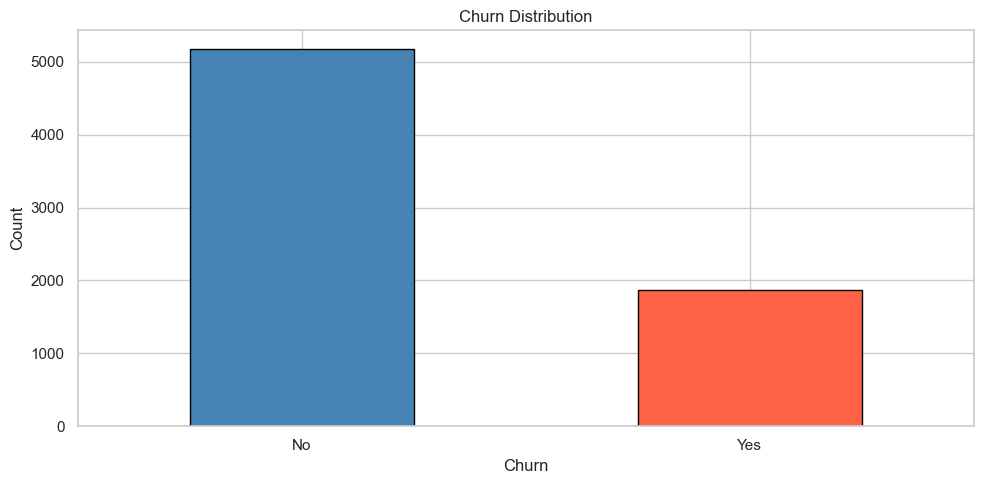

In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))

churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Numerical Features

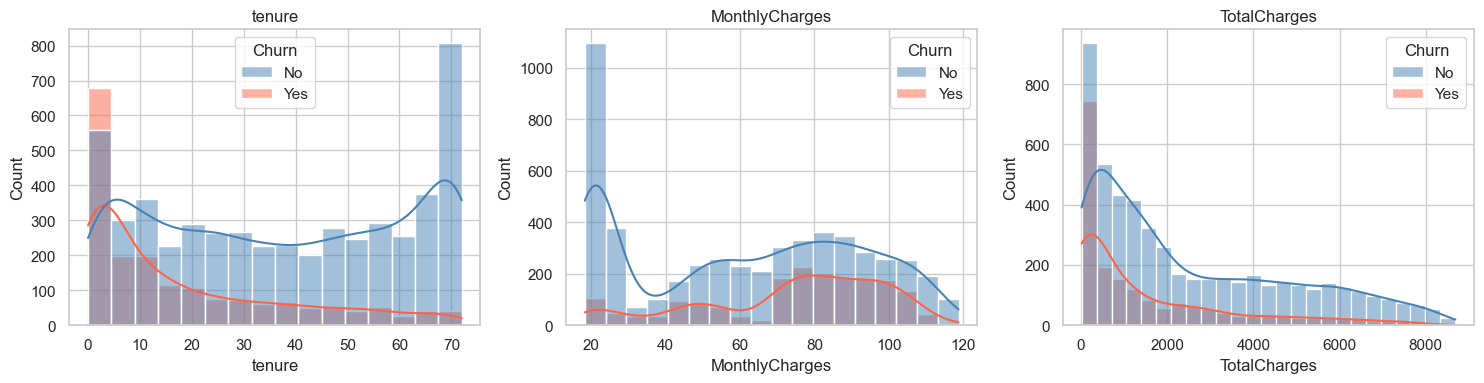

In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, palette=['steelblue', 'tomato'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

C:\Users\rajni\AppData\Local\Temp\ipykernel_2404\1224311167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['steelblue', 'tomato'])
C:\Users\rajni\AppData\Local\Temp\ipykernel_2404\1224311167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['steelblue', 'tomato'])
C:\Users\rajni\AppData\Local\Temp\ipykernel_2404\1224311167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['steelblue', 'tomato'])


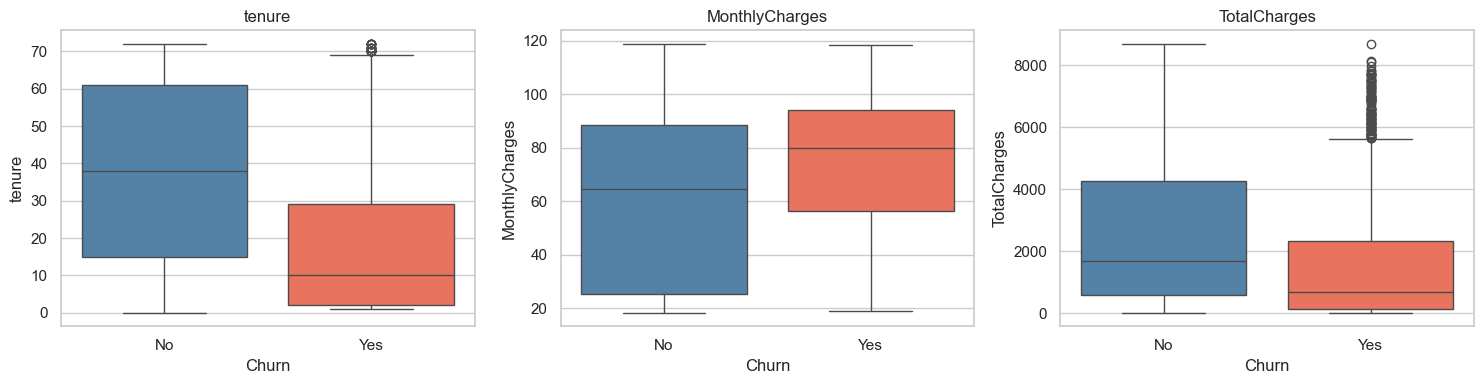

In [9]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['steelblue', 'tomato'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 7. Categorical Features

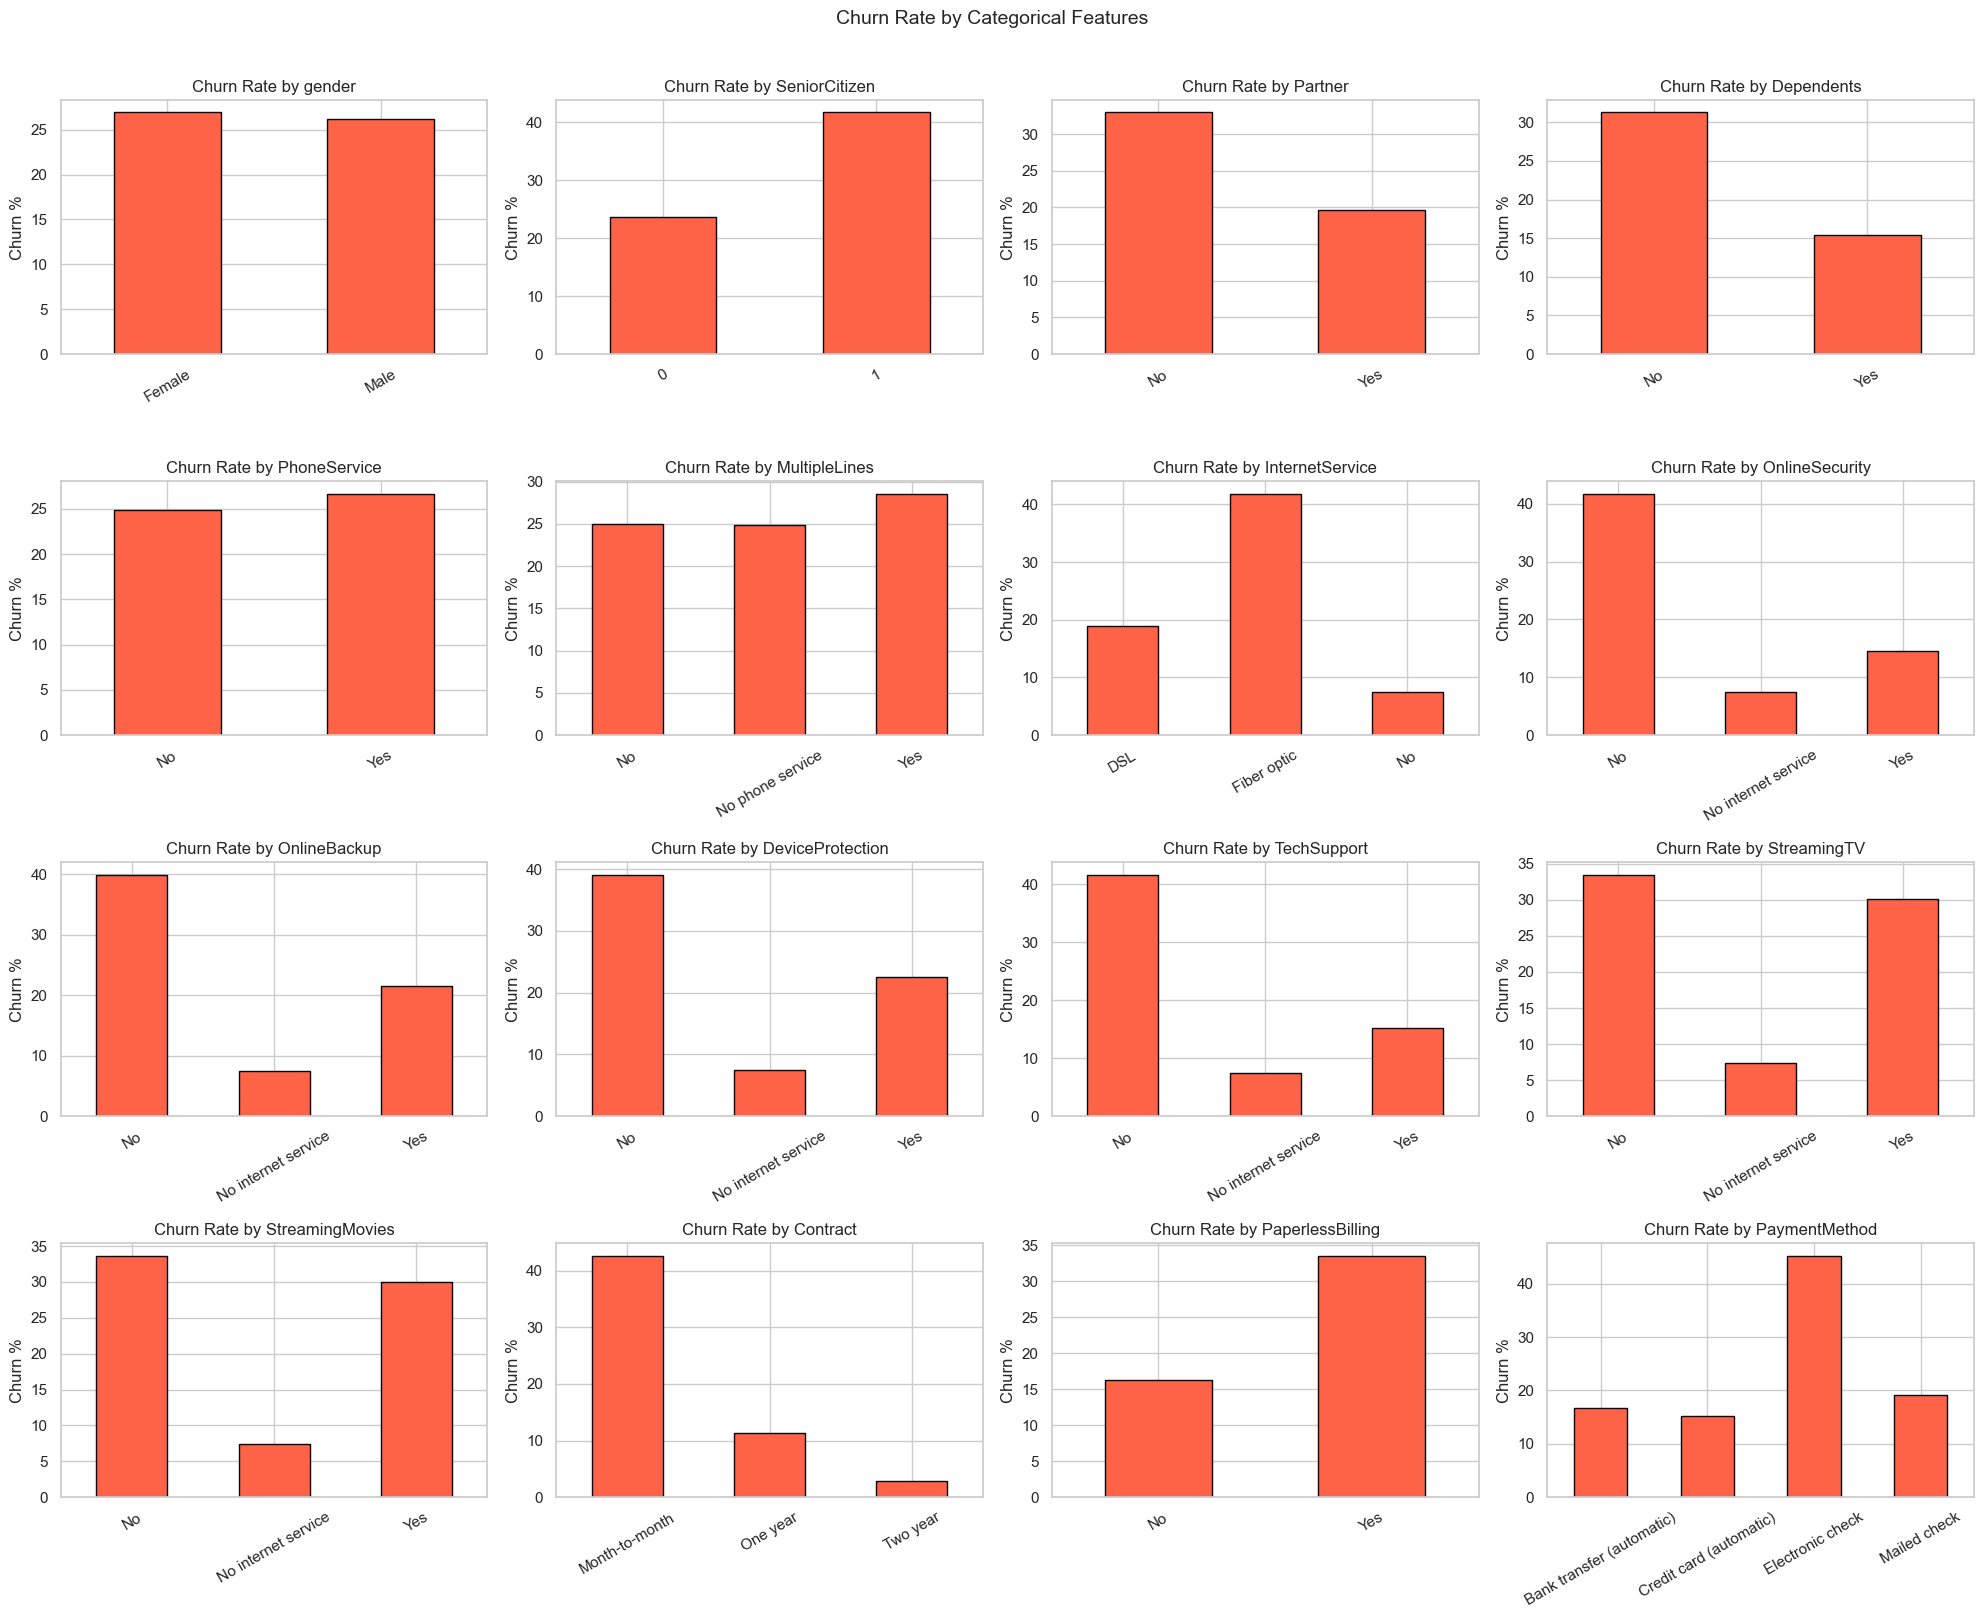

In [10]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn %')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

# Hide unused subplots
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap (Numerical)

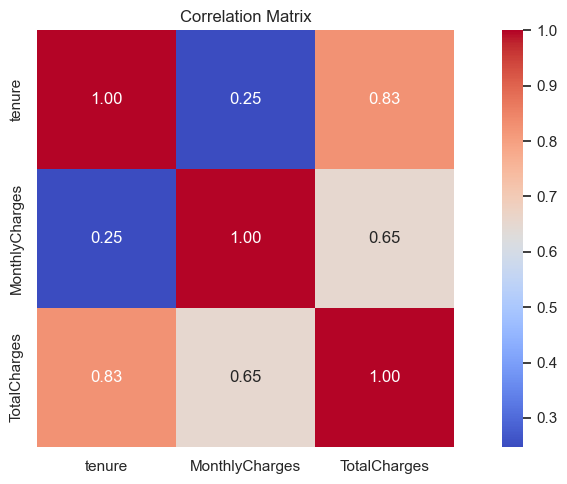

In [11]:
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Tenure vs Churn

C:\Users\rajni\AppData\Local\Temp\ipykernel_2404\1662331502.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)


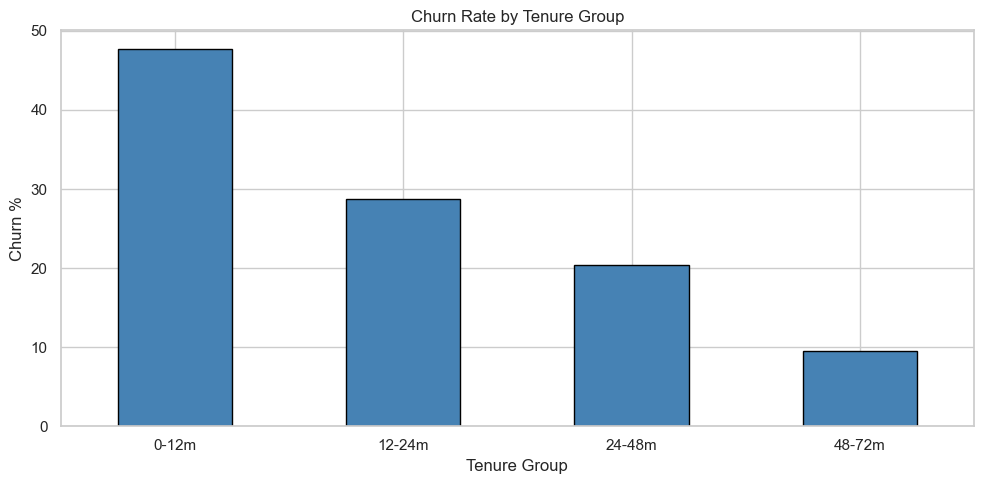

In [12]:
# Tenure buckets
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12m', '12-24m', '24-48m', '48-72m'])

churn_by_tenure = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_by_tenure.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Contract Type vs Churn

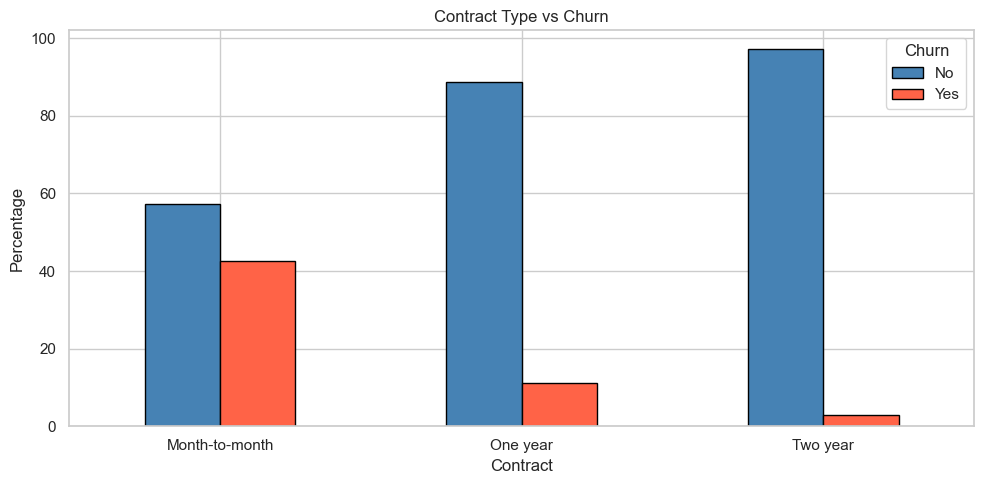

In [13]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Contract Type vs Churn')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## 11. Key Observations

- **Class imbalance**: ~26% churn vs ~74% no-churn — needs to be handled in modeling.
- **Tenure**: Short-tenure customers churn the most. Long-tenure customers are more loyal.
- **Contract type**: Month-to-month contracts have significantly higher churn rates.
- **MonthlyCharges**: Churned customers tend to have higher monthly charges.
- **TotalCharges**: Highly correlated with tenure — low TotalCharges = new customers = higher churn risk.
- **Internet Service**: Fiber optic customers churn more than DSL or No-internet customers.
- **Add-ons** (OnlineSecurity, TechSupport, etc.): Customers without these services churn more.